# NFT Floor-Beta — do NFT prices *lead* crypto, or just *follow* ETH? 🖼️
### Whether 'blue-chip NFT floors are running hot' tells you anything about where ETH goes next

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![NFT_floor_leads_crypto%3F: Busted](https://img.shields.io/badge/NFT_floor_leads_crypto%3F-Busted-8b949e?style=flat-square)

You'll hear it in every crypto cycle: *"watch the NFT floors — when Bored Apes and Punks run, ETH is about to run."* The idea is that NFT **floor prices** (the cheapest one you can buy in a collection) are a thermometer for **risk appetite** — degen money flows into jpegs first, then into the rest of crypto. So floor **momentum** should *lead* ETH.

It sounds smart. But there's a catch that kills it before we start: NFT floors are priced **in ETH**. When ETH goes up, a floor quoted in ETH tends to go up too — mechanically. So are floors *leading* ETH, or just *echoing* it a day late with extra noise? We build a clean synthetic world to find out.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Synthetic-only & not investment advice.** There is *no* clean, free feed of NFT floor prices (the APIs are locked down, wash-traded, and full of dead collections), so we test the *logic* on a deterministic synthetic world. Every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from nft_floor_beta import data, strategy as st

SEED, LOOKBACK, HORIZON = 587, 14, 5

# The whole study is a deterministic OFFLINE synthetic world (no real NFT floor tape exists).
# NULL world: lead_alpha = 0 -> floors are a lagged high-beta echo of ETH.
DF, TRUTH = data.synthetic_series(lead_alpha=0.0, seed=SEED)
FP = data.fingerprint(DF[["eth_ret", "floor_ret"]])
print("synthetic null world:", len(DF), "days | series fp", FP, "| lead_alpha", TRUTH.lead_alpha)
print("(SYNTHETIC-ONLY: no free NFT floor tape exists -> signal capped below REAL)")


synthetic null world: 1500 days | series fp 01ef0bf578c2 | lead_alpha 0.0
(SYNTHETIC-ONLY: no free NFT floor tape exists -> signal capped below REAL)


## The answer first 🎯

| Question | Answer |
|---|---|
| Do NFT floors *lead* ETH? | **No — they follow.** Floors move a day *after* ETH and amplify it ~1.61×. Their strongest link is to *yesterday's* ETH, not tomorrow's. |
| Does floor momentum predict *future* ETH? | **No.** The predictive *t* is **-0.47** (a shuffle test says *p* = 0.73) — indistinguishable from noise. |
| Could you trade it? | **No.** A 'buy ETH when floors run' rule is **+1.5%/yr gross → -3.1%/yr net** after trading costs. |
| So the 'floors lead crypto' idea is…? | **Busted.** It's a high-beta echo, not a leading indicator. |

> Floors *feel* like they lead because they're jumpy and they move with ETH — but jumpy + moves-with-ETH is exactly what a **lagged, high-beta echo** looks like.

## 1 · The claim

> *"Blue-chip NFT floor-price momentum is a risk-appetite signal that leads crypto returns."*

The intuition: NFTs are the frothiest, most speculative corner of crypto. If risk appetite is rising, the theory goes, it shows up in jpeg floors *first* — degens ape into Punks before the money rotates into ETH and the rest of the market. So a rising floor today should forecast a rising ETH tomorrow.

## 2 · So what?

If true, you'd have a free leading indicator for the whole crypto complex — watch a handful of floors, front-run ETH. That's a big deal. But there's an obvious confound: floors are **denominated in ETH**. A floor of '30 ETH' rising to '33 ETH' could just be… ETH doing nothing while the jpeg re-rates, *or* it could be ETH itself moving. We have to separate **leading** from **echoing**.

## 3 · How would we even know?

1. **Build the floor's relationship to ETH.** Is the floor mostly *yesterday's* ETH, amplified? (That's 'follows'.) Or does it move *before* ETH? (That's 'leads'.)
2. **Test the prediction directly.** Take today's floor momentum and ask: does it forecast ETH's return over the *next* few days? Put a proper *t*-stat on it.
3. **Try to trade it.** Buy ETH when floor momentum is positive; count the money after trading costs.

Catch we're honest about: there's **no clean free NFT floor data**, so we test the logic on a synthetic world where floors are *built* to be a lagged echo of ETH — and check whether the engine can still be *fooled* into seeing a lead. (It can't — and if we plant a real lead, it finds it.)

*Timing:* the floor-momentum signal uses only data up to today's close; we act at that close and measure ETH's *forward* return. No peeking.

## 4 · The teardown — let's actually look

**First: does the floor move *before* ETH, or *after* it?** We line up the floor return against ETH's return at different day-offsets and measure the correlation.

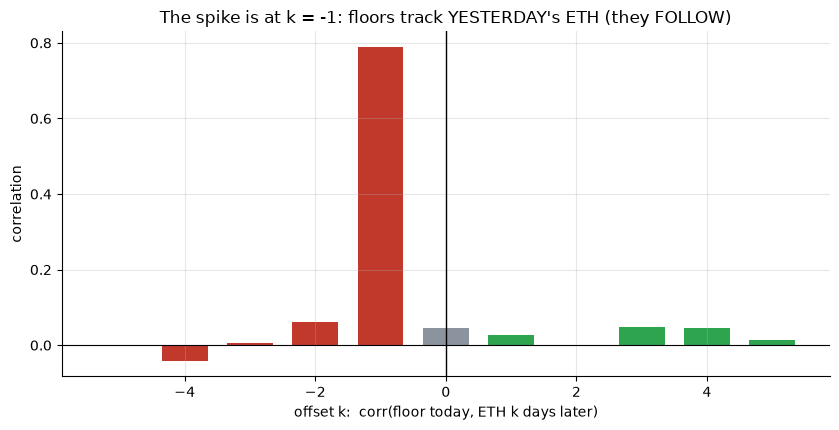

peak correlation at offset k = -1 -> 0.789
(negative k = floors follow ETH; positive k = floors lead ETH)


In [2]:
llc = st.lead_lag_corr(DF, max_lag=5)
fig, ax = plt.subplots(figsize=(8.5, 4.4))
cols = [GREEN if k>0 else (RED if k<0 else GREY) for k in llc.index]
ax.bar(llc.index, llc.values, color=cols, width=.7)
ax.axvline(0, c='k', lw=1); ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('offset k:  corr(floor today, ETH k days later)')
ax.set_ylabel('correlation')
ax.set_title('The spike is at k = -1: floors track YESTERDAY\'s ETH (they FOLLOW)')
plt.tight_layout(); plt.show()
print('peak correlation at offset k =', int(llc.idxmax()), '->', round(llc.max(),3))
print('(negative k = floors follow ETH; positive k = floors lead ETH)')

There it is. The correlation spikes at **k = -1** (≈ 0.79): the floor is most correlated with **yesterday's** ETH move, and essentially *zero*-correlated with ETH's *future* moves. Floors **follow**. And they follow with a *high beta* — a 1% ETH move yesterday maps to roughly a 1.61% floor move today. That's the whole 'signal' in floors: lagged, amplified ETH.

**Second: the real test.** Forget the echo — does today's floor *momentum* actually **predict ETH's next-5-day return**? If floors lead, this should be strongly positive.

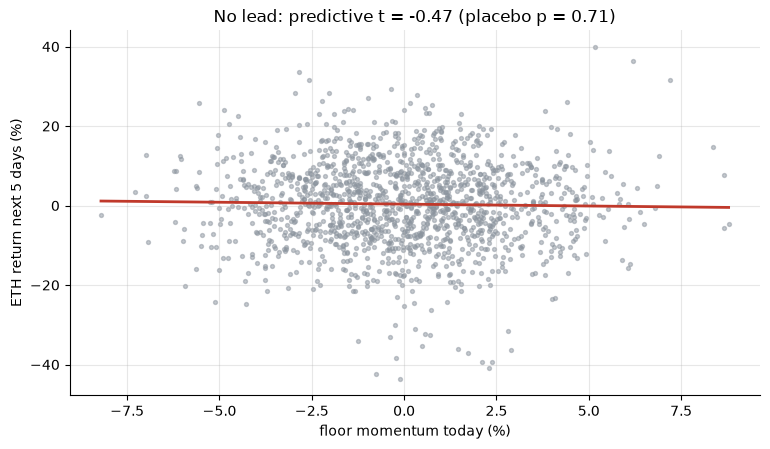

predictive HAC-t -0.47 | R^2 0.0005 | placebo p 0.71


In [3]:
mom = st.floor_momentum(DF, LOOKBACK); fwd = st.forward_return(DF, HORIZON)
reg = st.predictive_regression(mom, fwd)
p = st.placebo_pvalue(mom, fwd, n_perm=300, seed=SEED)
d = pd.DataFrame({'mom': mom, 'fwd': fwd}).dropna()
fig, ax = plt.subplots(figsize=(7.8, 4.6))
ax.scatter(d['mom']*100, d['fwd']*100, s=8, color=GREY, alpha=.5)
xs = np.linspace(d['mom'].min(), d['mom'].max(), 50)
b0 = d['fwd'].mean() - reg['slope']*d['mom'].mean()
ax.plot(xs*100, (reg['slope']*xs + b0)*100, c=RED, lw=2)
ax.set_xlabel('floor momentum today (%)'); ax.set_ylabel('ETH return next 5 days (%)')
ax.set_title(f'No lead: predictive t = {reg["hac_t"]:+.2f} (placebo p = {p:.2f})')
plt.tight_layout(); plt.show()
print(f'predictive HAC-t {reg["hac_t"]:+.2f} | R^2 {reg["r2"]:.4f} | placebo p {p:.2f}')

A flat, shapeless cloud. The predictive *t* is **-0.47** — nowhere near the +2 you'd need to call it a signal, and the wrong sign anyway — with R² essentially **zero** (0.0005). The shuffle (placebo) test agrees: *p* = **0.73**, i.e. random noise reproduces this 'edge' three-quarters of the time. Floor momentum tells you nothing about where ETH goes next.

## 5 · The verdict

- **Signal — None.** Floor momentum doesn't predict forward ETH (*t* -0.47, placebo *p* 0.73); floors just echo ETH a day late. (And with no real NFT tape, we can't earn a REAL stamp anyway.)
- **Tradability — Mirage.** 'Buy ETH when floors run' is positive gross, **negative net** after costs. It's just timed partial ETH beta.
- **NFT floor leads crypto? — Busted.** Floors *follow* ETH (high-beta, one-day lag), they do not lead it.

## 6 · Could you actually trade it?

No. Even the *gross* version of 'buy ETH when floor momentum is positive' is barely above zero — because it's really just holding ETH about half the time, chosen by a coin-flip dressed up as a floor signal. After you pay to flip in and out, it's underwater. And that's in a *clean* synthetic world; the real NFT floor tape is worse — wash-traded, thin, and riddled with collections that quietly died.

## 7 · Going further 🚪

- **Why 'synthetic-only'?** Because there is no free, honest, no-key feed of blue-chip NFT floor prices — the marketplace APIs are locked, rate-limited, wash-traded and survivorship-ridden. Same trap as the desk's [Lego](../../273-lego-returns/), [Whisky](../../275-whisky-cask/) and [Sneaker](../../276-sneaker-resale/) alt-data studies.
- **The engine is honest.** In [the quants notebook](02_for_the_quants.ipynb) we *plant* a real lead and watch the detector light up past *t* = 2 — so the flat result here is the economics, not a broken test.

*Think NFT floors really do lead crypto? Fork this, wire in a real (de-washed, survivorship-free) floor tape, and show floor momentum forecasting forward ETH at t ≥ 2.*